In [1]:
import os, hds
import pandas as pd
import numpy as np
from plt_rcs import *

In [2]:
plt.rc(group='figure', figsize=(12, 4))

In [3]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [4]:
os.chdir('../../data')

In [5]:
[i for i in os.listdir() if 'Bike' in i]

['Seoul_Bike_Prep.pkl', 'Seoul_Bike_Daily_2021_2025.csv']

In [6]:
[i for i in os.listdir() if 'Weather' in i]

['Seoul_Weather_Daily_2021_2025.xlsx', 'Seoul_Weather_Prep.pkl']

In [7]:
objs_bike = pd.read_pickle('Seoul_Bike_Prep.pkl')
objs_exog = pd.read_pickle('Seoul_Weather_Prep.pkl')

In [8]:
globals().update(objs_bike | objs_exog)

In [13]:
%who_ls DataFrame

['df', 'exog', 'exog_test', 'exog_train', 'test', 'train']

In [11]:
df, exog, exog_test, exog_train, test, train = df, exog, exog_test, exog_train, test, train

## XGBoost 모델용 데이터 생성 함수 정의

In [14]:
def make_xgb_features(target, exog=None):
    df = target.copy()
    df['lag_1'] = df['USE_CNT'].shift(1)
    df['lag_7'] = df['USE_CNT'].shift(7)
    df['roll_avg_7'] = df['lag_1'].rolling(window=7).mean()
    df['roll_std_7'] = df['lag_1'].rolling(window=7).std()
    df['month'] = df.index.month
    df['dayofweek'] = df.index.dayofweek
    if exog is not None:
        df = pd.merge(left=df, right=exog, how='left', left_index=True, right_index=True)
    return df

## 학습 데이터 생성

In [15]:
xgb_train = make_xgb_features(target=train, exog=exog_train)

In [17]:
xgb_train.head(10)

,USE_CNT,lag_1,lag_7,roll_avg_7,roll_std_7,month,dayofweek,ta_max,rn_sum,hm_avg,ss_sum
RENT_DT,,,,,,,,,,,
2021-01-01,21873.0,NaN,NaN,NaN,NaN,1,4,1.4,0.0,64.916667,1558
2021-01-02,23185.0,21873.0,NaN,NaN,NaN,1,5,-1.5,0.0,39.125000,939
2021-01-03,21410.0,23185.0,NaN,NaN,NaN,1,6,-2.3,0.0,44.416667,1066
2021-01-04,32436.0,21410.0,NaN,NaN,NaN,1,0,0.2,0.0,48.875000,1173
2021-01-05,28598.0,32436.0,NaN,NaN,NaN,1,1,-2.1,0.0,54.250000,1302
2021-01-06,21896.0,28598.0,NaN,NaN,NaN,1,2,-2.2,2.2,53.875000,1293
2021-01-07,5472.0,21896.0,NaN,NaN,NaN,1,3,-8.3,0.1,51.208333,1229
2021-01-08,7894.0,5472.0,21873.0,22124.285714,8438.894333,1,4,-11.2,0.0,44.625000,1071
2021-01-09,8918.0,7894.0,23185.0,20127.285714,10015.084035,1,5,-7.7,0.0,45.000000,1080


In [18]:
xgb_train = xgb_train.dropna()

In [19]:
xgb_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1441 entries, 2021-01-08 to 2024-12-31
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   USE_CNT     1441 non-null   float64
 1   lag_1       1441 non-null   float64
 2   lag_7       1441 non-null   float64
 3   roll_avg_7  1441 non-null   float64
 4   roll_std_7  1441 non-null   float64
 5   month       1441 non-null   int32  
 6   dayofweek   1441 non-null   int32  
 7   ta_max      1441 non-null   float64
 8   rn_sum      1441 non-null   float64
 9   hm_avg      1441 non-null   float64
 10  ss_sum      1441 non-null   int64  
dtypes: float64(8), int32(2), int64(1)
memory usage: 123.8 KB


## 특성 행렬과 타겟 벡터로 분리

In [20]:
yvar = 'USE_CNT'

In [21]:
X_train = xgb_train.drop(columns=yvar)
y_train = xgb_train[yvar].copy()

In [23]:
display(X_train.head())
display(y_train.head())

,lag_1,lag_7,roll_avg_7,roll_std_7,month,dayofweek,ta_max,rn_sum,hm_avg,ss_sum
RENT_DT,,,,,,,,,,
2021-01-08,5472.0,21873.0,22124.285714,8438.894333,1,4,-11.2,0.0,44.625000,1071
2021-01-09,7894.0,23185.0,20127.285714,10015.084035,1,5,-7.7,0.0,45.000000,1080
2021-01-10,8918.0,21410.0,18089.142857,10716.278387,1,6,-2.8,0.0,53.708333,1289
2021-01-11,10887.0,32436.0,16585.857143,10909.135536,1,0,-4.1,0.0,62.291667,1495
2021-01-12,19185.0,28598.0,14692.857143,8607.165628,1,1,-0.7,2.6,76.958333,1847


RENT_DT
2021-01-08     7894.0
2021-01-09     8918.0
2021-01-10    10887.0
2021-01-11    19185.0
2021-01-12    12607.0
Name: USE_CNT, dtype: float64

## XGBoost 회귀 모델 학습

In [24]:
from xgboost import XGBRegressor

In [25]:
xgb_model = XGBRegressor(
    n_estimators=100, max_depth=3,
    learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=0
)

In [26]:
xgb_model.fit(X=X_train, y=y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [28]:
xgb_test = make_xgb_features(target=test, exog=exog_test)

In [30]:
X_test = xgb_test.drop(columns=yvar)
y_test = xgb_test[yvar].copy()

In [31]:
xgb_model.score(X=X_test, y=y_test)

0.8304314615559962

In [32]:
xgb_pred_direct = xgb_model.predict(X=X_test)

In [33]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=xgb_pred_direct)

,metric,score,description
0,R^2,8.304315e-01,R Squared
1,MSE,3.047862e+08,Mean Squared Error
2,RMSE,1.745813e+04,Root Mean Squared Error
3,MSLE,6.946978e-02,Mean Squared Log Error
4,RMSLE,2.635712e-01,Root Mean Squared Log Error
5,MAE,1.174664e+04,Mean Absolute Error
6,MAPE,1.886494e-01,Mean Absolute Percentage Error


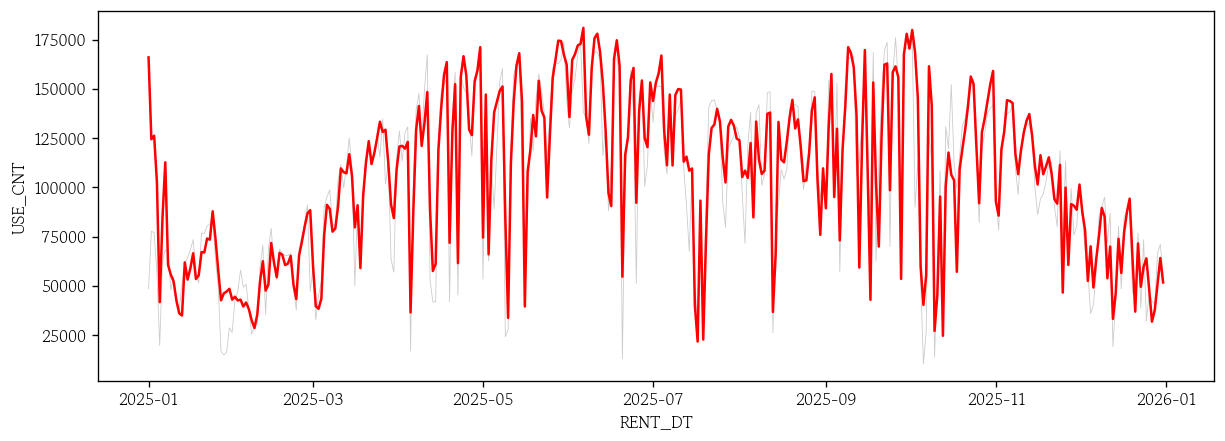

In [34]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=xgb_pred_direct, color='red');

## 순차 예측 함수 정의

In [38]:
def xgb_recursive_forecast(train, test, exog_train, exog_test, model):
    history = train.copy() # 원본 훈련셋 얕은 복사
    preds = [] # 모델 예측값을 하나씩 저장할 빈 리스트 생성

    for date in test.index: # 시험셋 인덱스 기준으로 반복 실행
        na_row = pd.DataFrame(data={'USE_CNT': [np.nan]}, index=[date])
        target_cur = pd.concat([history, na_row])
        exog_cur = pd.concat([exog_train, exog_test.loc[:date]])
        feat_cur = make_xgb_features(target=target_cur, exog=exog_cur)
        X_cur = feat_cur.loc[[date], model.feature_names_in_].fillna(0)
        yhat = model.predict(X=X_cur)[0]
        preds.append(yhat)
        history.loc[date, 'USE_CNT'] = yhat

    xgb_pred = pd.Series(data=preds, index=test.index, name='yhat')
    
    return xgb_pred

## XGBoost 회귀 모델의 예측값 생성

In [39]:
xgb_pred = xgb_recursive_forecast(
    train=train, test=test,
    exog_train=exog_train,
    exog_test=exog_test,
    model=xgb_model
)

In [40]:
xgb_pred.head()

RENT_DT
2025-01-01    75278.539062
2025-01-02    74372.390625
2025-01-03    70856.117188
2025-01-04    54359.976562
2025-01-05    21457.695312
Freq: D, Name: yhat, dtype: float32

## XGBoost 회귀 모델 잔차 시각화

In [41]:
xgb_resid = test['USE_CNT'] - xgb_pred

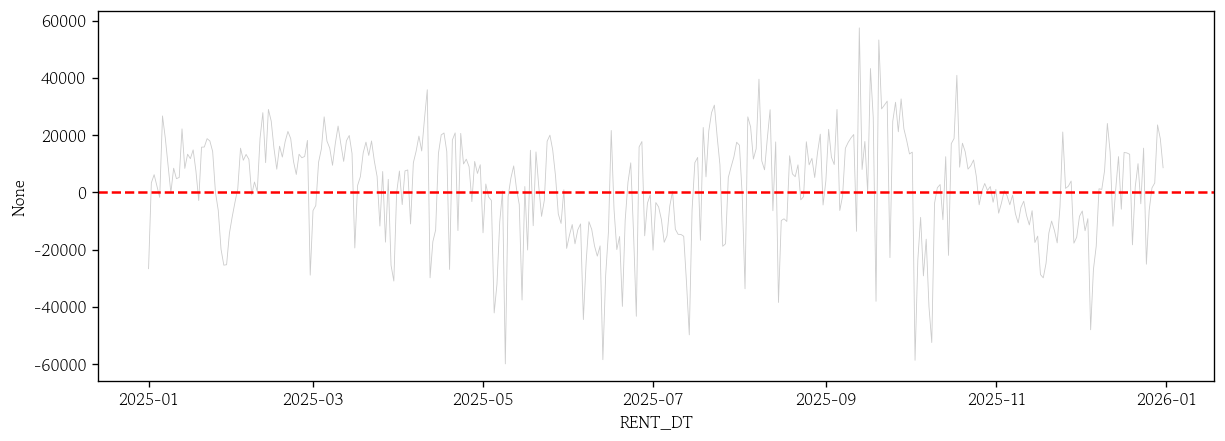

In [42]:
sns.lineplot(x=test.index, y=xgb_resid, color='0.8', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

## XGBoost 회귀 모델 잔차 자기상관 시각화

In [43]:
from statsmodels.graphics.tsaplots import plot_acf

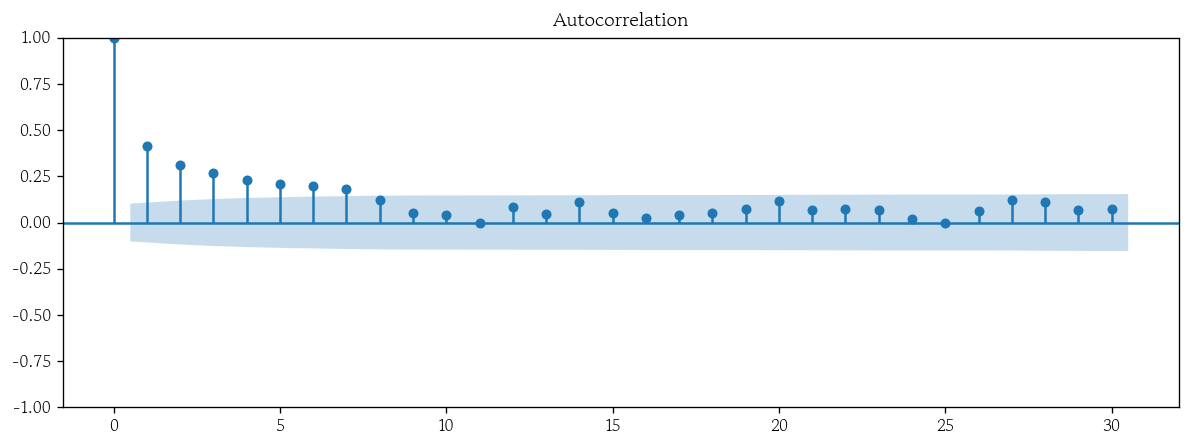

In [44]:
plot_acf(x=xgb_resid, lags=30);

## XGBoost 회귀 모델 예측값 시각화

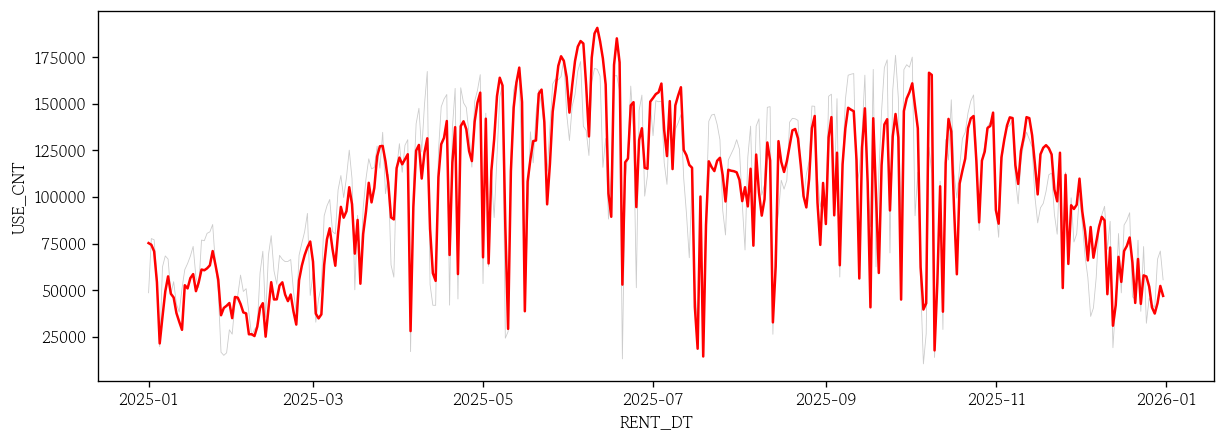

In [45]:
sns.lineplot(x=test.index, y=test['USE_CNT'], color='0.8', linewidth=0.5)
sns.lineplot(x=test.index, y=xgb_pred, color='red');

## XGBoost 회귀 모델 예측 성능 확인

In [46]:
hds.stat.regmetrics(y_true=test['USE_CNT'], y_pred=xgb_pred)

,metric,score,description
0,R^2,8.116421e-01,R Squared
1,MSE,3.385585e+08,Mean Squared Error
2,RMSE,1.839996e+04,Root Mean Squared Error
3,MSLE,7.043489e-02,Mean Squared Log Error
4,RMSLE,2.653957e-01,Root Mean Squared Log Error
5,MAE,1.471254e+04,Mean Absolute Error
6,MAPE,2.000963e-01,Mean Absolute Percentage Error
